In [4]:
import sklearn

In [5]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.05,
                    random_state=42)

In [6]:
len(X), len(y)

(1000, 1000)

In [7]:
import pandas as pd
circles = pd.DataFrame({"X0": X[:, 0],
                        "X1": X[:, 1],
                        "label": y})

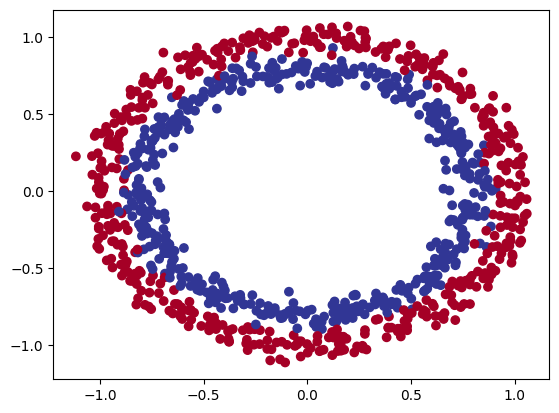

In [8]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [9]:
#turning the pandas data frame into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,
                                                     y,
                                                     test_size=0.2,
                                                     random_state=42)

In [11]:
len(x_train), len(x_test)

(800, 200)

In [12]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
class CircleModelV0(nn.Module):
     def __init__(self):
         super().__init__()
    #     self.layer_1 = nn.Linear(in_features=2,
    #                              out_features=5)
    #     self.layer_2 = nn.Linear(in_features=5,
    #                              out_features=1)

    # def forward(self, x):
    #     return self.layer_2(self.layer_1(x))
         self.two_linear_layer = nn.Sequential(
                nn.Linear(in_features=2, out_features=5),
                nn.Linear(in_features=5, out_features=1)
         )
     def forward(self, x):
        return self.two_linear_layer(x)

In [14]:
# Ensure the CircleModelV0 class is defined before this cell
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (two_linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [15]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.1)

In [16]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred))*100
    return acc

In [17]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(x_test.to(device))
y_logits[:5]  

tensor([[-0.0660],
        [-0.1085],
        [ 0.1853],
        [-0.1447],
        [ 0.4002]], device='cuda:0')

In [18]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [19]:
y_pred_prob = torch.sigmoid(y_logits)
y_pred_prob[:5]

tensor([[0.4835],
        [0.4729],
        [0.5462],
        [0.4639],
        [0.5987]], device='cuda:0')

In [20]:
torch.round(y_pred_prob[:5])

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

In [21]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 100
for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(x_train.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train.to(device))
    acc = accuracy_fn(y_true=y_train.cpu(),
                      y_pred=y_pred.cpu())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Testing the model
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(x_test.to(device)).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test.to(device))
        test_acc = accuracy_fn(y_true=y_test.cpu(),
                               y_pred=test_pred.cpu())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% |Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70188 | Accuracy: 52.50% |Test Loss: 0.69387 | Test Accuracy: 52.00%
Epoch: 10 | Loss: 0.69831 | Accuracy: 50.88% |Test Loss: 0.69190 | Test Accuracy: 52.50%
Epoch: 20 | Loss: 0.69666 | Accuracy: 50.25% |Test Loss: 0.69127 | Test Accuracy: 52.50%
Epoch: 30 | Loss: 0.69574 | Accuracy: 50.25% |Test Loss: 0.69107 | Test Accuracy: 53.00%
Epoch: 40 | Loss: 0.69515 | Accuracy: 49.50% |Test Loss: 0.69105 | Test Accuracy: 54.00%
Epoch: 50 | Loss: 0.69476 | Accuracy: 49.62% |Test Loss: 0.69111 | Test Accuracy: 54.50%
Epoch: 60 | Loss: 0.69448 | Accuracy: 49.00% |Test Loss: 0.69121 | Test Accuracy: 54.00%
Epoch: 70 | Loss: 0.69428 | Accuracy: 48.50% |Test Loss: 0.69132 | Test Accuracy: 53.50%
Epoch: 80 | Loss: 0.69412 | Accuracy: 49.25% |Test Loss: 0.69144 | Test Accuracy: 53.50%
Epoch: 90 | Loss: 0.69401 | Accuracy: 48.88% |Test Loss: 0.69155 | Test Accuracy: 53.50%


In [22]:
y_logit = model_0(x_test.to(device)).squeeze()
y_logits[:5]

tensor([-0.0048,  0.0173,  0.0577,  0.0624, -0.0436], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [23]:
import requests
from pathlib import Path

# Download the helper functions from GitHub
if Path("helper_function.py").is_file():
    print("helper_function.py already exists, skipping download.")
else:
    print("Downloading helper_function.py...")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_function.py", "wb") as f:
        f.write(request.content)


helper_function.py already exists, skipping download.


In [24]:
from helper_function import plot_decision_boundary,plot_predictions

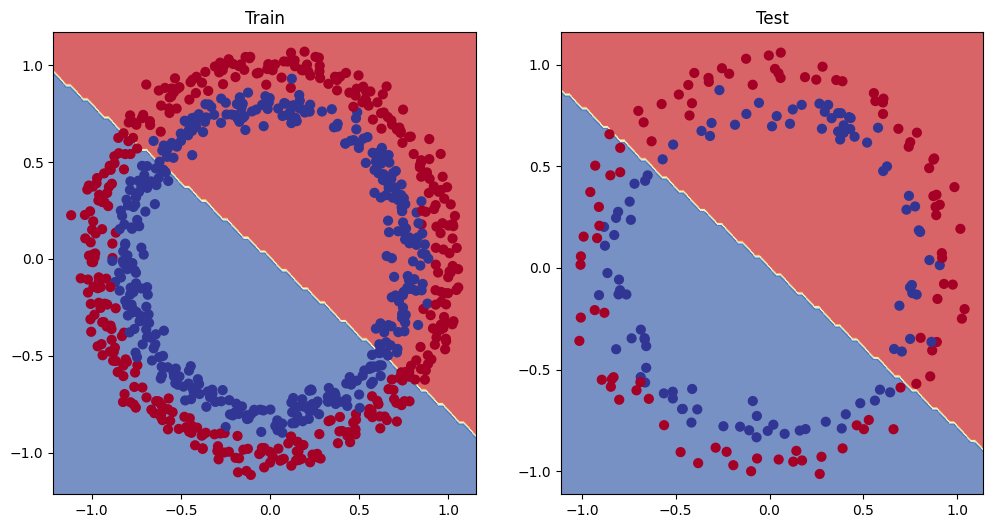

In [25]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, x_train.cpu(), y_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, x_test.cpu(), y_test.cpu())

In [26]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,
                                 out_features=10)
        self.layer_2 = nn.Linear(in_features=10,
                                    out_features=10)
        self.layer_3 = nn.Linear(in_features=10,
                                    out_features=1)
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))
model_1 = CircleModelV0().to(device)
model_1

CircleModelV0(
  (two_linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [27]:
#create a loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_1.parameters(),
                            lr=0.1)

In [28]:
#create a training loop and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 1000
for epoch in range(epochs):
    model_1.train()

    y_logits = model_1(x_train.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train.to(device))
    acc = accuracy_fn(y_true=y_train.cpu(),
                      y_pred=y_pred.cpu())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Testing the model
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(x_test.to(device)).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test.to(device))
        test_acc = accuracy_fn(y_true=y_test.cpu(),
                               y_pred=test_pred.cpu())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% |Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69569 | Accuracy: 50.00% |Test Loss: 0.69721 | Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.69404 | Accuracy: 50.00% |Test Loss: 0.69615 | Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.69344 | Accuracy: 45.75% |Test Loss: 0.69585 | Test Accuracy: 47.00%
Epoch: 30 | Loss: 0.69322 | Accuracy: 49.38% |Test Loss: 0.69576 | Test Accuracy: 47.00%
Epoch: 40 | Loss: 0.69313 | Accuracy: 49.50% |Test Loss: 0.69572 | Test Accuracy: 47.00%
Epoch: 50 | Loss: 0.69309 | Accuracy: 50.25% |Test Loss: 0.69568 | Test Accuracy: 46.50%
Epoch: 60 | Loss: 0.69307 | Accuracy: 50.25% |Test Loss: 0.69563 | Test Accuracy: 46.00%
Epoch: 70 | Loss: 0.69305 | Accuracy: 50.62% |Test Loss: 0.69558 | Test Accuracy: 47.00%
Epoch: 80 | Loss: 0.69304 | Accuracy: 50.62% |Test Loss: 0.69552 | Test Accuracy: 47.00%
Epoch: 90 | Loss: 0.69303 | Accuracy: 50.62% |Test Loss: 0.69547 | Test Accuracy: 46.50%
Epoch: 100 | Loss: 0.69303 | Accuracy: 50.75% |Test Loss: 0.69541 | Test Accuracy: 46.00%
Epoch: 110 | Loss: 0.

In [29]:
class CircleV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,
                                 out_features=10)
        self.layer_2 = nn.Linear(in_features=10,
                                    out_features=10)
        self.layer_3 = nn.Linear(in_features=10,
                                    out_features=1)
        self.relue = nn.ReLU()
    def forward(self, x):
        return self.layer_3(self.relue(self.layer_2(self.relue(self.layer_1(x)))))
model_3 = CircleV3().to(device)
model_3

CircleV3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relue): ReLU()
)

In [30]:
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.1)
loss_fn = nn.BCEWithLogitsLoss()

In [31]:
from torch import manual_seed


import torch  # Importing torch to access cuda

manual_seed(42)
torch.cuda.manual_seed(42)  # Updated to use torch.cuda
epochs = 1000
for epoch in range(epochs):
    model_3.train()

    y_logits = model_3(x_train.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train.to(device))
    acc = accuracy_fn(y_true=y_train.cpu(),
                      y_pred=y_pred.cpu())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Testing the model
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(x_test.to(device)).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test.to(device))
        test_acc = accuracy_fn(y_true=y_test.cpu(),
                               y_pred=test_pred.cpu())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% |Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295 | Accuracy: 50.00% |Test Loss: 0.69329 | Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.69251 | Accuracy: 51.38% |Test Loss: 0.69275 | Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.69227 | Accuracy: 59.75% |Test Loss: 0.69246 | Test Accuracy: 55.50%
Epoch: 30 | Loss: 0.69212 | Accuracy: 69.25% |Test Loss: 0.69227 | Test Accuracy: 63.50%
Epoch: 40 | Loss: 0.69197 | Accuracy: 66.12% |Test Loss: 0.69210 | Test Accuracy: 68.50%
Epoch: 50 | Loss: 0.69183 | Accuracy: 58.75% |Test Loss: 0.69193 | Test Accuracy: 60.50%
Epoch: 60 | Loss: 0.69169 | Accuracy: 55.12% |Test Loss: 0.69179 | Test Accuracy: 54.50%
Epoch: 70 | Loss: 0.69156 | Accuracy: 53.25% |Test Loss: 0.69165 | Test Accuracy: 52.00%
Epoch: 80 | Loss: 0.69143 | Accuracy: 52.88% |Test Loss: 0.69152 | Test Accuracy: 51.50%
Epoch: 90 | Loss: 0.69130 | Accuracy: 52.75% |Test Loss: 0.69139 | Test Accuracy: 51.50%
Epoch: 100 | Loss: 0.69117 | Accuracy: 52.75% |Test Loss: 0.69126 | Test Accuracy: 52.50%
Epoch: 110 | Loss: 0.

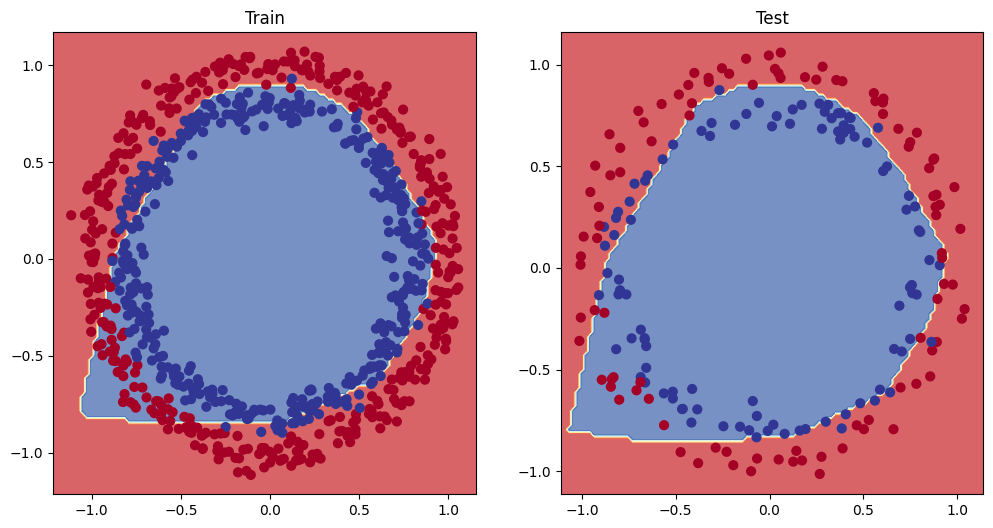

In [32]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, x_train.cpu(), y_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, x_test.cpu(), y_test.cpu())



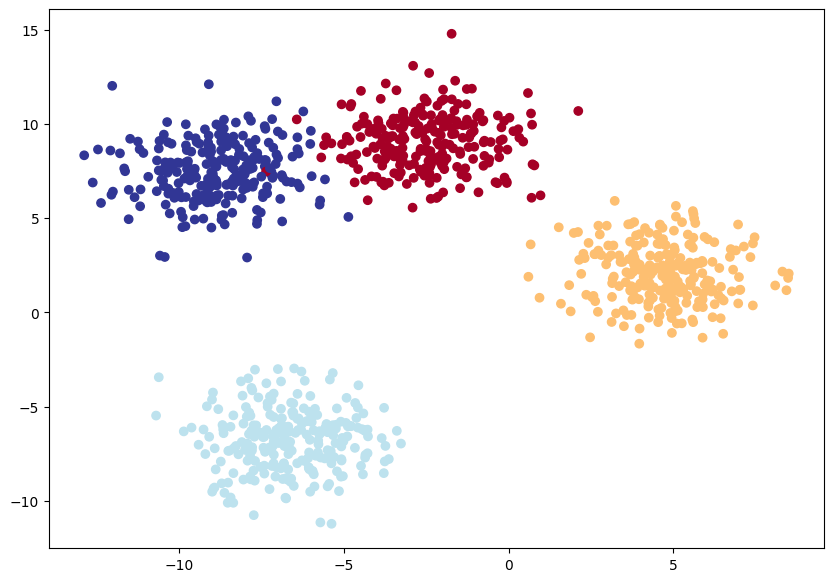

In [33]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_ClASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000,
                            centers=NUM_ClASSES,
                            n_features=NUM_FEATURES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

#now we turn them into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)

x_blob_train, x_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [34]:
import torch.nn as nn
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes the BlobModel.  
        Args: 
            input_features: Number of features in the input data.
            output_features: Number of classes for classification.
            hidden_units: Number of units in the hidden layer (default is 8).
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features,
                                 out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                                    out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                                    out_features=output_features))
    def forward(self, x):
        return self.linear_layer_stack(x)
    
device = "cuda" if torch.cuda.is_available() else "cpu"
model_4 = BlobModel(input_features=2, output_features=4, hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1)

In [36]:
model_4(x_blob_test.to(device))

tensor([[-7.6459e-01, -7.4120e-01, -1.5777e+00, -1.1376e+00],
        [-9.7256e-02, -9.4310e-01, -5.9631e-01, -1.3715e-01],
        [ 2.5277e-01, -2.3794e-01,  1.8817e-01, -6.5686e-03],
        [-4.1340e-01, -5.2042e-01, -9.3033e-01, -6.9626e-01],
        [-3.1184e-01, -1.3736e+00, -1.1991e+00, -3.8337e-01],
        [-1.4971e-01, -1.0617e+00, -7.1069e-01, -1.6452e-01],
        [ 1.5388e-01, -2.8874e-01,  1.5199e-01, -1.0874e-02],
        [-2.1543e-01, -1.1795e+00, -9.3000e-01, -2.7448e-01],
        [ 2.4432e-01, -2.4716e-01,  1.6492e-01,  6.1044e-03],
        [-2.3286e-01, -1.2120e+00, -9.8487e-01, -3.0037e-01],
        [-1.7742e-01, -1.1008e+00, -8.2929e-01, -2.3689e-01],
        [-9.4082e-01, -7.8985e-01, -1.8480e+00, -1.3347e+00],
        [-2.9723e-01, -1.3458e+00, -1.1543e+00, -3.6287e-01],
        [-2.9006e-01, -1.3393e+00, -1.1146e+00, -3.3518e-01],
        [-3.3713e-01, -1.4374e+00, -1.2379e+00, -3.8029e-01],
        [-1.0260e-01, -9.5066e-01, -6.1913e-01, -1.5105e-01],
        

In [37]:
#training loop for multi class clissification
from torch import argmax


torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 1000

for epoch in range(epochs):
    model_4.train()
    y_logits = model_4(x_blob_train.to(device))
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    loss = loss_fn(y_logits, y_blob_train.to(device))
   
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(x_blob_test.to(device))
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_blob_test.to(device))

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")


Epoch: 0 | Loss: 1.15883 | Test Loss: 1.07554
Epoch: 100 | Loss: 0.03312 | Test Loss: 0.02433
Epoch: 200 | Loss: 0.02657 | Test Loss: 0.01651
Epoch: 300 | Loss: 0.02503 | Test Loss: 0.01440
Epoch: 400 | Loss: 0.02427 | Test Loss: 0.01335
Epoch: 500 | Loss: 0.02377 | Test Loss: 0.01269
Epoch: 600 | Loss: 0.02339 | Test Loss: 0.01218
Epoch: 700 | Loss: 0.02307 | Test Loss: 0.01179
Epoch: 800 | Loss: 0.02279 | Test Loss: 0.01147
Epoch: 900 | Loss: 0.02253 | Test Loss: 0.01120


In [38]:
y_blob_train[:5]

tensor([1, 0, 2, 2, 0])

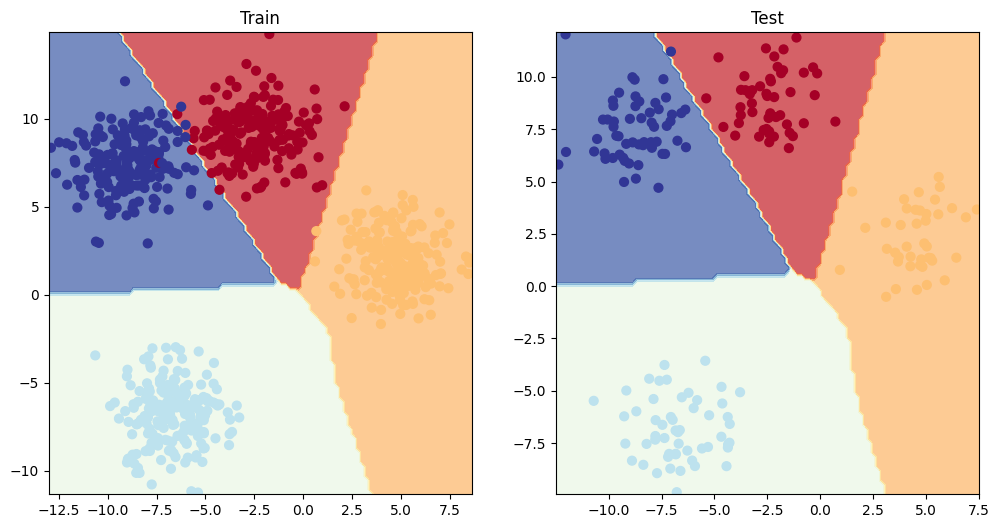

In [39]:
#visualize the decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, x_blob_train.cpu(), y_blob_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, x_blob_test.cpu(), y_blob_test.cpu())


In [44]:
from torchmetrics import Accuracy
torch_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

torch_accuracy(test_pred, y_blob_test.to(device))

tensor(0.9950, device='cuda:0')